In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('payment detail.csv')
data.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [3]:
data.info()

data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 485.4+ MB


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00


In [4]:
#Colomns with number of null values
data.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [5]:
#Count of all types of Transaction
data.type.value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

<Axes: xlabel='type', ylabel='count'>

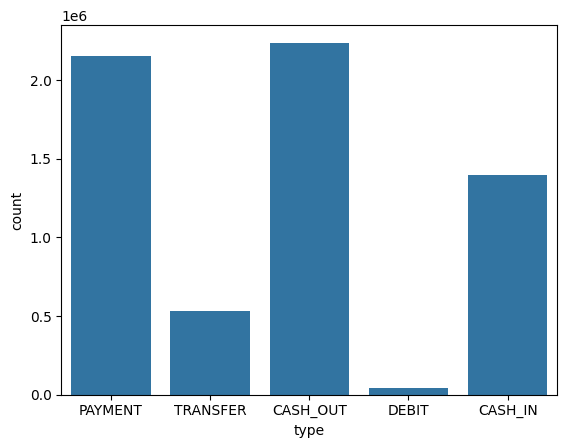

In [ ]:
#
sns.countplot(x='type', data=data)


<Axes: xlabel='type', ylabel='amount'>

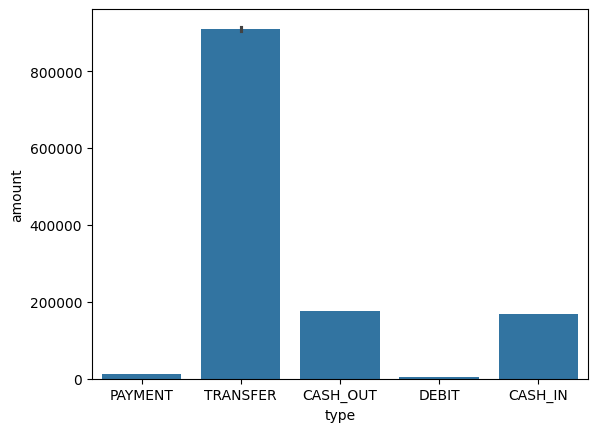

In [ ]:
# A barchart showing the amount of transactions done via different transaction methods
sns.barplot(x='type', y='amount', data=data)

<Figure size 1500x600 with 0 Axes>

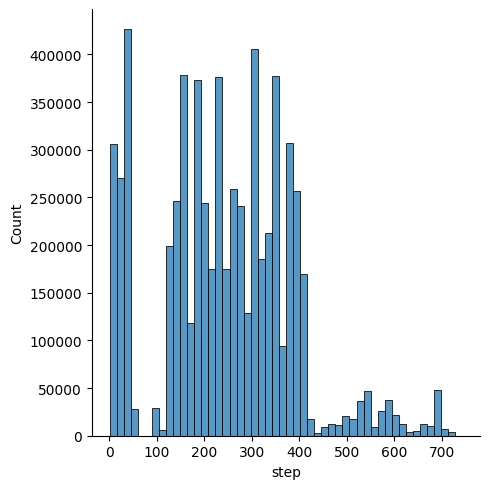

In [15]:
plt.figure(figsize=(15, 6))
sns.displot(data['step'], bins=50)


In [ ]:
# Counting the number of Fraud(1) and Not fraud(0) in the dataset
data['isFraud'].value_counts()                                    

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [ ]:
# Converting the type of transaction into numbers for easy learning
data['type'] = data['type'].map({"CASH_OUT": 1, "PAYMENT": 2, "CASH_IN": 3, "TRANSFER": 4, "DEBIT": 5})

# Converting '0' to Not Fraud and '1' to Fraud
data['isFraud'] = data["isFraud"].map({0: "Not Fraud", 1: "Fraud"})
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,2,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,Not Fraud
1,1,2,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,Not Fraud
2,1,4,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,Fraud
3,1,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,Fraud
4,1,2,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,Not Fraud


In [ ]:
# Storing type, amount, oldbalanceOrg, newbalanceOrig into 'X' as an array
X = np.array(data[['type','amount','oldbalanceOrg','newbalanceOrig']])

# Storing isFraud into 'Y' as an array
Y = np.array(data[['isFraud']])
X.shape,Y.shape

((6362620, 4), (6362620, 1))

In [ ]:

# Using Decision Tree Classicification for understanding the dataset
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

model = DecisionTreeClassifier()

# Training
model.fit(X_train,y_train)
# Testing
model.score(X_test,y_test)

0.9996888074409599

In [35]:

#prediction = model.predict([[4, 181.10, 181.10, 0]])
prediction = model.predict([[1, 2334.12, 23334.12, 0]])
print(prediction)

['Fraud']
